
<style>
.ormedian-callout {
  border-left: 6px solid #24ABCF;
  background: #F6F8FA;
  padding: 14px 18px;
  margin: 12px 0;
  border-radius: 4px;
  color: #0B1F3B;
}
.ormedian-warning {
  border-left: 6px solid #1281B2;
  background: #EEF5F8;
  padding: 14px 18px;
  margin: 12px 0;
  border-radius: 4px;
  color: #0B1F3B;
}
.ormedian-checkpoint {
  border: 1px solid #B9DCE8;
  background: #FFFFFF;
  padding: 14px 18px;
  margin: 12px 0;
  border-radius: 8px;
  color: #0B1F3B;
}
</style>

<p align="center">
  <img src="../assets/ormedian_session1_banner.png" alt="Ormedian AI Engineering Fundamentals Session 1" width="100%" />
</p>

# Week 1 independent assignment

Complete this notebook during the week. It must run from a fresh kernel using **Run All** and it must tell a coherent story: problem, data, baseline, model, evaluation, errors, experiment and conclusion.



## Submission contract

- Write explanations in your own words.
- Do not use the test set to choose settings.
- Change one main experimental variable.
- Record wrong predictions, not just scores.
- Do not submit code you cannot explain.
- Use relative paths only.



# 0. Setup

Run this complete setup cell. Add no hidden manual steps.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
if not (ROOT / "data").exists():
    raise RuntimeError("Start Jupyter from the repository folder.")

sys.path.insert(0, str(ROOT))

from src.data import dataset_summary, get_splits, load_dataset, validate_dataset
from src.evaluation import classification_metrics, error_frame
from src.modelling import build_majority_baseline, build_text_model

DATA_PATH = ROOT / "data" / "processed" / "support_intents.csv"
RANDOM_SEED = 42
print("Ready. Repository root:", ROOT)

Ready. Repository root: c:\Users\tunmi\Desktop\AI-learning-folder\AI-Engineering-Fundamentals-Student\Session-1



# 1. Problem statement

Write one paragraph explaining the imagined support problem.

Then complete:

| Item | Your answer |
|---|---|
| Input |A customer support message written in plain English|
| Output |One of the support intent labels |
| User/payer |Support agents and the operations team |
| Action supported |Automatically decide the purpose of each message so it can be routed to the right team (billing, technical support, refunds, etc.)|
| Costly false route | Examples of what happens when it gets it wrong like wastes the agent's time and frustrates the customer |
| Main evaluation metric |Validation macro F1 |
| Out of scope |things the system won't handle |


let's assume e want a customer support system that receives text messages from customers. The system needs to automatically understand the purpose of each message and send it to the right team like billing, technical support, or refunds. If it sends the message to the wrong team, it wastes the agent's time and frustrates the customer. To do this, we will train a text classifier on past labeled messages and test how well it can predict the correct intent for new messages.



In [2]:
# No model code in this cell.
# Optionally store your framing as a dictionary and display it.
problem = {
    "input": "A customer support message written in plain English",
    "output": "One of the support intent labels",
    "user": "Support agents and customer service operations",
    "costly_mistake": "Routing a refund request to the wrong queue or missing a technical issue",
    "metric": "Validation macro F1, with accuracy as a secondary check",
}
problem

{'input': 'A customer support message written in plain English',
 'output': 'One of the support intent labels',
 'user': 'Support agents and customer service operations',
 'costly_mistake': 'Routing a refund request to the wrong queue or missing a technical issue',
 'metric': 'Validation macro F1, with accuracy as a secondary check'}


# 2. Load and understand the data

Load the processed data, validate it and show:

- Shape.
- Column names.
- First five rows.
- Number of labels.
- Class distribution.
- Split distribution.
- Blank text count.
- Duplicate text-label count.


In [3]:
data = load_dataset(DATA_PATH)
validate_dataset(data)

print("Shape:", data.shape)
print("Columns:", list(data.columns))
print("\nFirst five rows:")
display(data.head())
print("\nNumber of labels:", data["label"].nunique())

Shape: (180, 6)
Columns: ['example_id', 'text', 'label', 'split', 'difficulty', 'source']

First five rows:


,example_id,text,label,split,difficulty,source
0,gen-020,How many users can one account have?,general_enquiry,train,medium,curated_synthetic
1,can-024,I want to back out of the order.,cancel_order,validation,hard,curated_synthetic
2,ref-016,When will my refund reach my bank account?,refund_request,train,medium,curated_synthetic
3,can-013,Please stop order 5519 immediately.,cancel_order,train,medium,curated_synthetic
4,ref-014,The wrong amount was taken; I need a refund.,refund_request,train,medium,curated_synthetic



Number of labels: 6


In [4]:
summary = dataset_summary(data)
summary

{'n_examples': 180,
 'n_labels': 6,
 'class_distribution': {'account_update': 30,
  'cancel_order': 30,
  'general_enquiry': 30,
  'invoice_status': 30,
  'refund_request': 30,
  'technical_support': 30},
 'split_distribution': {'test': 30, 'train': 120, 'validation': 30},
 'blank_text': 0,
 'duplicate_text_label_pairs': 0,
 'average_text_length_characters': 39.28888888888889}

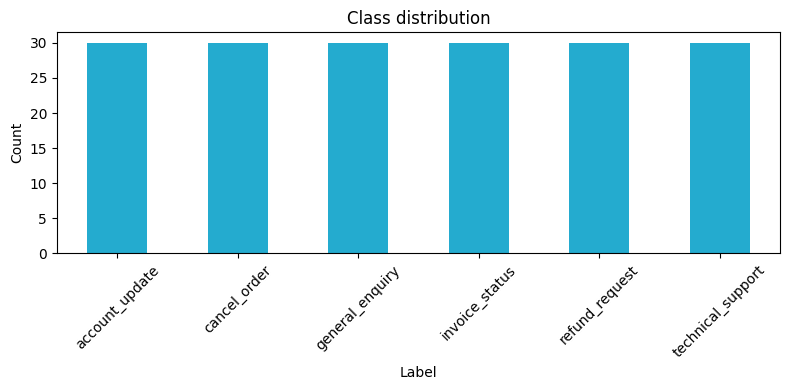

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
(data["label"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#24ABCF"))
ax.set_title("Class distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Data interpretation

Answer:

1. What is one example?
the support message and the label : row
2. What is the feature?
the text column is the feature
3. What is the target?
the label column is the target
4. Which columns are metadata?
5. Which columns would create leakage if passed to the model? The columns that would create leakage if passed tothe model is the training columns
6. What important real-world language is not represented by this synthetic dataset?



# 3. Separate train, validation and test

Create the three frames and verify there is no `example_id` overlap.


In [6]:
train, validation, test = get_splits(data)

print("Train size:", len(train))
print("Validation size:", len(validation))
print("Test size:", len(test))

train_ids = set(train["example_id"])
validation_ids = set(validation["example_id"])
test_ids = set(test["example_id"])

print("No overlap between splits:", not (train_ids & validation_ids) and not (train_ids & test_ids) and not (validation_ids & test_ids))

Train size: 120
Validation size: 30
Test size: 30
No overlap between splits: True



Explain why:

- Training performance is not enough.
Training performance is not enough because the model memorise the training data
- Validation may guide experiments.
- Test should be opened only after a model choice.
To avoid overfitting



# 4. Majority baseline

Fit the majority baseline and evaluate it on validation data.


In [7]:
baseline = build_majority_baseline()
baseline.fit(train[["text"]], train["label"])

baseline_pred = baseline.predict(validation["text"])
baseline_metrics = classification_metrics(validation["label"], baseline_pred)

print("Baseline accuracy:", round(baseline_metrics["accuracy"], 4))
print("Baseline macro F1:", round(baseline_metrics["macro_f1"], 4))
print("Baseline weighted F1:", round(baseline_metrics["weighted_f1"], 4))
print("\nClassification report:\n", baseline_metrics["classification_report"])

Baseline accuracy: 0.1667
Baseline macro F1: 0.0476
Baseline weighted F1: 0.0476

Classification report:
 {'account_update': {'precision': 0.16666666666666666, 'recall': 1.0, 'f1-score': 0.2857142857142857, 'support': 5.0}, 'cancel_order': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}, 'general_enquiry': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}, 'invoice_status': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}, 'refund_request': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}, 'technical_support': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}, 'accuracy': 0.16666666666666666, 'macro avg': {'precision': 0.027777777777777776, 'recall': 0.16666666666666666, 'f1-score': 0.047619047619047616, 'support': 30.0}, 'weighted avg': {'precision': 0.027777777777777776, 'recall': 0.16666666666666666, 'f1-score': 0.04761904761904761, 'support': 30.0}}



Interpret the baseline. What would it mean if the real model failed to beat it?

If the real model cannot beat this baseline, it means the model has learned nothing useful from the text.


# 5. Main model: TF-IDF unigrams plus logistic regression


In [8]:
unigram_model = build_text_model(ngram_range=(1, 1))
unigram_model.fit(train["text"], train["label"])

unigram_pred = unigram_model.predict(validation["text"])


In [9]:
unigram_metrics = classification_metrics(validation["label"], unigram_pred)

print("Accuracy:", round(unigram_metrics["accuracy"], 4))
print("Macro F1:", round(unigram_metrics["macro_f1"], 4))
print("Weighted F1:", round(unigram_metrics["weighted_f1"], 4))
print("\nClassification report:\n")
print(classification_report(validation["label"], unigram_pred, zero_division=0))

Accuracy: 0.7667
Macro F1: 0.7626
Weighted F1: 0.7626

Classification report:

                   precision    recall  f1-score   support

   account_update       0.75      0.60      0.67         5
     cancel_order       1.00      0.60      0.75         5
  general_enquiry       0.57      0.80      0.67         5
   invoice_status       1.00      0.60      0.75         5
   refund_request       0.71      1.00      0.83         5
technical_support       0.83      1.00      0.91         5

         accuracy                           0.77        30
        macro avg       0.81      0.77      0.76        30
     weighted avg       0.81      0.77      0.76        30



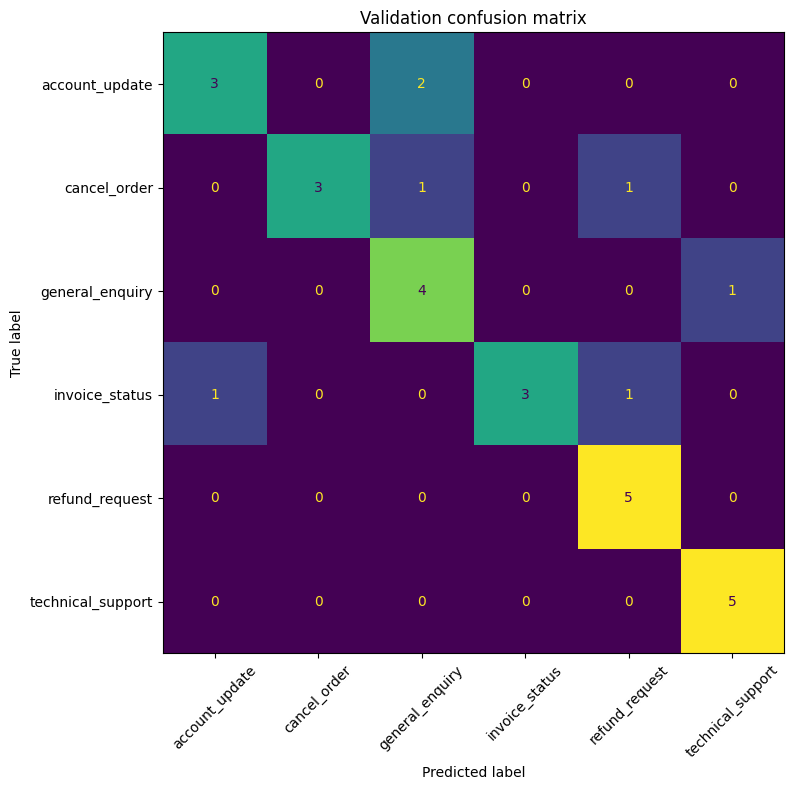

In [10]:
labels = sorted(data["label"].unique())
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    validation["label"],
    unigram_pred,
    labels=labels,
    xticks_rotation=45,
    values_format="d",
    ax=ax,
    colorbar=False,
)
ax.set_title("Validation confusion matrix")
plt.tight_layout()
plt.show()


## Metric interpretation

Choose two labels. For each, explain precision and recall in the context of support routing.

Refund

Precision: when the model says “refund”, it is usually correct, agents don't waste time on wrong tickets.

Recall: the model finds almost all real refund requests, customers who need a refund are not left waiting in the wrong queue.

Technical issue

Precision: When the model says "transaction failed", it is correct, agents don't waste time on rectifying the issue.

Recall: the model finds almost all failed transaction, customers that had issue with the transaction are not left waiting in the wrong queue.


# 6. Error analysis

Create a table of wrong validation predictions and analyse at least three.


In [11]:
errors = error_frame(validation["text"], validation["label"], unigram_pred)
errors.head(20)

,text,true_label,predicted_label
0,What happens after I sign up?,general_enquiry,technical_support
1,Can you replace the emergency contact?,account_update,general_enquiry
2,Did reference INV-204 clear successfully?,invoice_status,refund_request
3,I have a new work email to use.,account_update,general_enquiry
4,Do not send the parcel; I changed my mind.,cancel_order,refund_request
5,Can you call off the delivery?,cancel_order,general_enquiry
6,What remains unpaid on my account?,invoice_status,account_update



| Text | True | Predicted | Hypothesised cause | Data or model improvement |
|---|---|---|---|---|
|Pay me back for the unsatisfied item |refund |technical issue |Model saw the word "unsatisfied" and thought it was technical | |
| | | | | |
| | | | | |



# 7. Controlled experiment

Recommended change: `ngram_range=(1, 2)`.

Before running:

- **Question:**
- **Hypothesis:**
- **Variable changed:**
- **Variables held fixed:**
- **Success criterion:**


In [12]:
bigram_model = build_text_model(ngram_range=(1, 2))
bigram_model.fit(train["text"], train["label"])

bigram_pred = bigram_model.predict(validation["text"])
bigram_metrics = classification_metrics(validation["label"], bigram_pred)

print("Bigram accuracy:", round(bigram_metrics["accuracy"], 4))
print("Bigram macro F1:", round(bigram_metrics["macro_f1"], 4))
print("Bigram weighted F1:", round(bigram_metrics["weighted_f1"], 4))

Bigram accuracy: 0.7667
Bigram macro F1: 0.7663
Bigram weighted F1: 0.7663


In [13]:
comparison = pd.DataFrame(
    [
        {
            "model": "baseline",
            "accuracy": baseline_metrics["accuracy"],
            "macro_f1": baseline_metrics["macro_f1"],
            "weighted_f1": baseline_metrics["weighted_f1"],
        },
        {
            "model": "unigram",
            "accuracy": unigram_metrics["accuracy"],
            "macro_f1": unigram_metrics["macro_f1"],
            "weighted_f1": unigram_metrics["weighted_f1"],
        },
        {
            "model": "bigram",
            "accuracy": bigram_metrics["accuracy"],
            "macro_f1": bigram_metrics["macro_f1"],
            "weighted_f1": bigram_metrics["weighted_f1"],
        },
    ]
)
comparison

,model,accuracy,macro_f1,weighted_f1
0,baseline,0.166667,0.047619,0.047619
1,unigram,0.766667,0.762626,0.762626
2,bigram,0.766667,0.766330,0.766330



## Experiment interpretation

- What changed numerically?
- Did the hypothesis hold?
- Which errors disappeared or appeared?
- Is the difference large enough to matter on this small validation set?
- What would you repeat on a larger dataset?



# 8. Select and evaluate once on test

Use validation macro F1 to select the configuration. Then calculate final test metrics and errors.


In [14]:
selected_model_name = "bigram" if bigram_metrics["macro_f1"] >= unigram_metrics["macro_f1"] else "unigram"
selected_model = bigram_model if selected_model_name == "bigram" else unigram_model

selected_pred = selected_model.predict(test["text"])
selected_metrics = classification_metrics(test["label"], selected_pred)

print("Selected model:", selected_model_name)
print("Test accuracy:", round(selected_metrics["accuracy"], 4))
print("Test macro F1:", round(selected_metrics["macro_f1"], 4))
print("Test weighted F1:", round(selected_metrics["weighted_f1"], 4))
print("\nTest classification report:\n")
print(classification_report(test["label"], selected_pred, zero_division=0))

Selected model: bigram
Test accuracy: 0.8667
Test macro F1: 0.869
Test weighted F1: 0.869

Test classification report:

                   precision    recall  f1-score   support

   account_update       0.83      1.00      0.91         5
     cancel_order       0.67      0.80      0.73         5
  general_enquiry       1.00      0.80      0.89         5
   invoice_status       1.00      0.80      0.89         5
   refund_request       0.80      0.80      0.80         5
technical_support       1.00      1.00      1.00         5

         accuracy                           0.87        30
        macro avg       0.88      0.87      0.87        30
     weighted avg       0.88      0.87      0.87        30



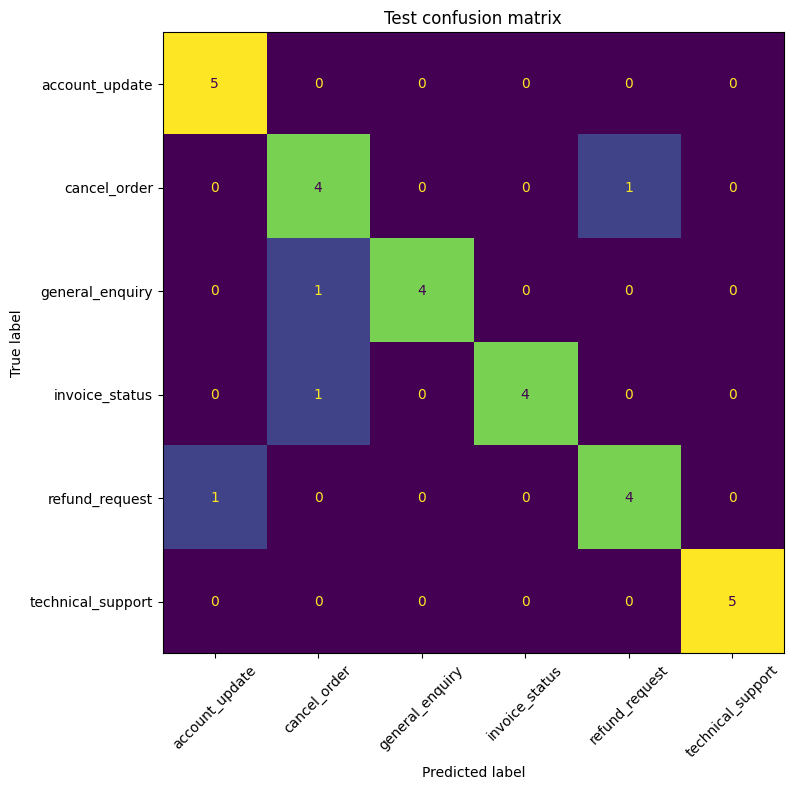


Test errors:


,text,true_label,predicted_label
0,I would like an overview before deciding.,general_enquiry,cancel_order
1,I need the current position on reference 9007.,invoice_status,cancel_order
2,Could you undo the charge on my account?,refund_request,account_update
3,Withdraw the request I submitted yesterday.,cancel_order,refund_request


In [15]:
labels = sorted(data["label"].unique())
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    test["label"],
    selected_pred,
    labels=labels,
    xticks_rotation=45,
    values_format="d",
    ax=ax,
    colorbar=False,
)
ax.set_title("Test confusion matrix")
plt.tight_layout()
plt.show()

print("\nTest errors:")
display(error_frame(test["text"], test["label"], selected_pred).head(20))


# 9. Final conclusion

Write 200-400 words covering:

1. The problem and data.
The data is a small set of English support messages with several intent labels. We split it into train, validation and test sets so the final score is honest
2. The baseline.
The baseline got a low macro F1 score
3. The chosen model.
it passed the baseline on the validation set.
4. Validation and test evidence.
5. Most important failure pattern.
The word “unsatisfiede” that appeared in refund message
6. Dataset limitations.
7. One next data improvement.
collect more real customer messages, especially for the classes that are mostly confused
8. One next modelling experiment.
9. Why the result is not production-ready.
The result is not ready for real use because the data is too small and the language is too clean compared with real support tickets



# 10. Self-assessment

- [ ] Notebook runs from a fresh kernel.
- [ ] All major sections contain Markdown explanation.
- [ ] I can explain every code cell.
- [ ] I did not tune on the test set.
- [ ] I inspected at least three errors.
- [ ] I changed one main variable.
- [ ] I recorded a conclusion supported by evidence.
- [ ] I completed the reflection questions and paper notes.


## Pedro Domingos, "A Few Useful Things to Know About Machine Learning".

## One-sentence summary
One functional model implementations resemble one another but every dysfunctional model implementation is dysfunctional in its own way.

## Five useful takeaways
1. if you hire someone to build a classifier , be sure to keep some of the data to yourself and test the classifier they give you on it.
2. If you have been hired to build a classifier, set some of the data aside from the beginning and only use it to test your chosen classifier at the very end.
3. Strong false assumption can be better than weak true ones, because a learner with the latter needs more data to avoid overfitting.
4. Learners combine knowledge with data to grow programs.
5. Cross validation can help to combat overfitting.

## Two unfamiliar terms
1. Term:
   My current understanding: if we have a lot of knowledge about what makes examples similar in our domain, instance based method may be a good choice of choosing a representation.
2. Term:
   My current understanding: If we have knowledge about what kind of preconditions are required by each class "if" rules may be the best option

## One point I disagree with or want to question
The point I want to question on is - strong false assumptions can be better than weak true ones.

## Difficult words
off-the-shelf optimizers
black art
intractable
Tenebaum
greedy-search
corollary
panacea
capricious
asymptotic
belaboring


